imblearn available: True
Loaded data shape: (284807, 31)
Class
0    284315
1       492
Name: count, dtype: int64
count    284807.000000
mean         88.349619
std         250.120109
min           0.000000
25%           5.600000
50%          22.000000
75%          77.165000
max       25691.160000
Name: Amount, dtype: float64
small dataset shape: (20492, 31) fraud fraction: 0.024009369510052704
Full train/test: (227845, 30) (56962, 30)
Small train/test: (16393, 30) (4099, 30)
Running FAST experiments on SMALL dataset — change RUN_FULL=True to run full
[small] None + LogisticRegression | test_acc=0.9756 | auc=0.9680972613989359 | n_train_after=16393
[small] None + RandomForest | test_acc=0.9956 | auc=0.9618029166177844 | n_train_after=16393
[small] None + XGBoost | test_acc=0.9946 | auc=0.9816015383909124 | n_train_after=16393
[small] SMOTE + LogisticRegression | test_acc=0.9729 | auc=0.9694362123754776 | n_train_after=31998
[small] SMOTE + RandomForest | test_acc=0.9954 | auc=0.982005774

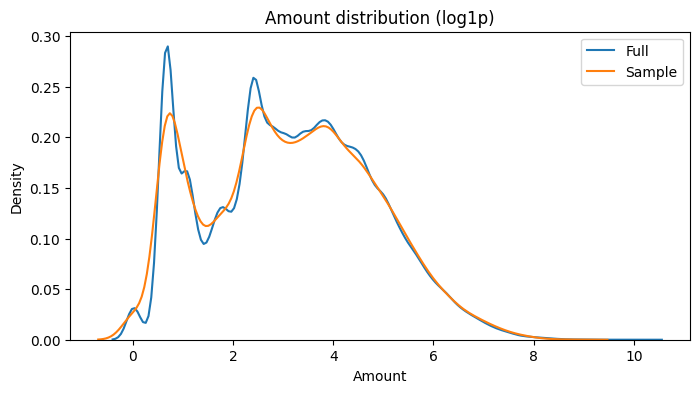

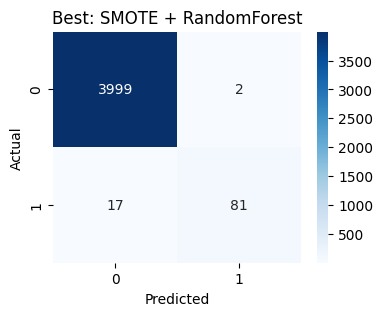

In [3]:
# Cost-Sensitive Credit Card Fraud Detection
# Clean, minimal, and correct pipeline for experiments with samplers and models
# Topic: cost-sensitive fraud detection using XGBoost, plus comparison with other models
# Author: Generated for user

# -----------------------------------------------------------------------------
# 1. NOTES / USAGE
# -----------------------------------------------------------------------------
# 1) Put this file into your notebook environment as a single Jupyter cell file
#    or paste block-by-block into notebook cells. Cells are separated by '# %%'
# 2) Install required packages before running (inside the correct venv):
#    python -m pip install -r requirements.txt
#    If you don't have requirements.txt, install at least:
#    python -m pip install numpy pandas scikit-learn xgboost imbalanced-learn matplotlib seaborn
# 3) Default behavior runs a *fast* experimental subset on a smaller sample to
#    keep iteration time short. To run the full experiments set RUN_FULL = True.
# -----------------------------------------------------------------------------

# %%
# CONFIG
RUN_FULL = False  # set True to run full experiments on the entire train set (slow)
RANDOM_STATE = 42
DATA_PATH = "../Data/creditcard.csv"  # change if file is elsewhere
RESULTS_CSV = "resampler_model_comparison.csv"

# Models and samplers to use when RUN_FULL == False (faster)
FAST_SAMPLERS = ["None", "SMOTE", "RandomOverSampler"]
FAST_MODELS = ["LogisticRegression", "RandomForest", "XGBoost"]

# When RUN_FULL == True these sets are used
ALL_SAMPLERS = [
    "None",
    "RandomOverSampler",
    "RandomUnderSampler",
    "ClusterCentroids",
    "TomekLinks",
    "SMOTE",
    "SMOTETomek",
]
ALL_MODELS = [
    "LogisticRegression",
    "KNN",
    "SVM",
    "DecisionTree",
    "RandomForest",
    "XGBoost",
]

# For visualization / debugging
PLOT_SAMPLE_SIZE = 10000

# %%
# IMPORTS
import warnings
warnings.filterwarnings("ignore")

import numpy as np
import pandas as pd
from copy import deepcopy
from pathlib import Path

# plotting
import matplotlib.pyplot as plt
import seaborn as sns

# sklearn
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import (
    accuracy_score,
    confusion_matrix,
    classification_report,
    roc_auc_score,
    precision_recall_curve,
    auc as sk_auc,
)
from sklearn.decomposition import PCA

# models
from sklearn.linear_model import LogisticRegression
from sklearn.neighbors import KNeighborsClassifier
from sklearn.svm import SVC
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
try:
    from xgboost import XGBClassifier
except Exception:
    XGBClassifier = None

# imblearn
try:
    from imblearn.over_sampling import RandomOverSampler, SMOTE
    from imblearn.under_sampling import RandomUnderSampler, ClusterCentroids, TomekLinks
    from imblearn.combine import SMOTETomek
    IMBLEARN_AVAILABLE = True
except Exception:
    IMBLEARN_AVAILABLE = False

print(f"imblearn available: {IMBLEARN_AVAILABLE}")

# %%
# UTILITIES

def load_data(path=DATA_PATH):
    df = pd.read_csv(path)
    return df


def compute_scale_pos_weight(y):
    # For XGBoost: ratio negative / positive in the training set
    neg = np.sum(y == 0)
    pos = np.sum(y == 1)
    if pos == 0:
        return 1.0
    return float(neg) / float(pos)

# safe predict_proba / decision

def safe_predict_score(model, X_test):
    """Return probability-like scores for AUC computations when possible."""
    y_score = None
    try:
        y_score = model.predict_proba(X_test)
        # if binary, select positive class
        if isinstance(y_score, np.ndarray):
            if y_score.ndim == 2 and y_score.shape[1] >= 2:
                y_score = y_score[:, 1]
            elif y_score.ndim == 2 and y_score.shape[1] == 1:
                y_score = y_score[:, 0]
            else:
                # fallback
                y_score = np.ravel(y_score)
    except Exception:
        try:
            y_score = model.decision_function(X_test)
            if isinstance(y_score, np.ndarray) and y_score.ndim > 1:
                if y_score.shape[1] == 2:
                    y_score = y_score[:, 1]
                else:
                    y_score = np.max(y_score, axis=1)
        except Exception:
            y_score = None
    return y_score

# %%
# LOAD AND QUICK EDA

df = load_data()
print("Loaded data shape:", df.shape)
print(df['Class'].value_counts())

# quick percentiles on Amount
print(df['Amount'].describe())

# %%
# Create a small stratified dataset for fast experiments and visualization
# Keep the full dataset untouched for final runs.

fraud = df[df['Class'] == 1]
legit = df[df['Class'] == 0]

# Keep all frauds, sample a subset of legits for faster iteration.
SMALL_LEGIT_N = 20000
if len(legit) > SMALL_LEGIT_N:
    legit_sample = legit.sample(n=SMALL_LEGIT_N, random_state=RANDOM_STATE)
else:
    legit_sample = legit.copy()

dataset_small = pd.concat([fraud, legit_sample]).sample(frac=1, random_state=RANDOM_STATE).reset_index(drop=True)
print("small dataset shape:", dataset_small.shape, "fraud fraction:", dataset_small['Class'].mean())

# %%
# Visual checks (log1p for Amount)
plt.figure(figsize=(8,4))
sns.kdeplot(np.log1p(df['Amount']), label='Full', bw_adjust=1)
sns.kdeplot(np.log1p(dataset_small['Amount']), label='Sample', bw_adjust=1)
plt.legend(); plt.title('Amount distribution (log1p)')

# %%
# Prepare features and split function

def prepare_Xy(dataframe):
    X = dataframe.drop(columns='Class')
    y = dataframe['Class']
    return X, y

X_full, y_full = prepare_Xy(df)
X_small, y_small = prepare_Xy(dataset_small)

# %%
# Correct train/test split on the full data (stratified)
# By default we'll use the smaller dataset to iterate quickly. Use full data for final runs.

X_train_full, X_test_full, y_train_full, y_test_full = train_test_split(
    X_full, y_full, test_size=0.2, stratify=y_full, random_state=RANDOM_STATE
)

X_train_small, X_test_small, y_train_small, y_test_small = train_test_split(
    X_small, y_small, test_size=0.2, stratify=y_small, random_state=RANDOM_STATE
)

print("Full train/test:", X_train_full.shape, X_test_full.shape)
print("Small train/test:", X_train_small.shape, X_test_small.shape)

# %%
# Scaling: fit scaler on TRAIN only. We'll scale only 'Amount' and 'Time' because V1..V28 are already PCA components.

def scale_amount_time(X_train, X_test):
    scaler = StandardScaler()
    cols = ['Time', 'Amount'] if 'Time' in X_train.columns else ['Amount']
    # fit scaler on train
    X_train_copy = X_train.copy()
    X_test_copy = X_test.copy()
    X_train_copy[cols] = scaler.fit_transform(X_train_copy[cols])
    X_test_copy[cols] = scaler.transform(X_test_copy[cols])
    return X_train_copy, X_test_copy, scaler

# Apply to small dataset (fast)
X_train_s_scaled, X_test_s_scaled, scaler_small = scale_amount_time(X_train_small, X_test_small)
# Apply to full only later when running full experiment

# %%
# Prepare samplers dictionary (if imblearn available)
if IMBLEARN_AVAILABLE:
    samplers = {
        "None": None,
        "RandomOverSampler": RandomOverSampler(random_state=RANDOM_STATE),
        "RandomUnderSampler": RandomUnderSampler(random_state=RANDOM_STATE),
        "ClusterCentroids": ClusterCentroids(random_state=RANDOM_STATE),
        "TomekLinks": TomekLinks(),
        "SMOTE": SMOTE(random_state=RANDOM_STATE),
        "SMOTETomek": SMOTETomek(random_state=RANDOM_STATE),
    }
else:
    samplers = {"None": None}

# Choose which samplers to use
if RUN_FULL:
    sampler_names = list(samplers.keys())
else:
    sampler_names = [s for s in FAST_SAMPLERS if s in samplers]

# %%
# Models dictionary factory (create new instances each run)

def get_models(scale_pos_weight=None):
    models = {
        "LogisticRegression": LogisticRegression(max_iter=5000, class_weight='balanced', random_state=RANDOM_STATE),
        "KNN": KNeighborsClassifier(n_neighbors=5),
        "SVM": SVC(probability=True, kernel='rbf', random_state=RANDOM_STATE),
        "DecisionTree": DecisionTreeClassifier(random_state=RANDOM_STATE),
        "RandomForest": RandomForestClassifier(n_estimators=200, random_state=RANDOM_STATE),
    }
    if XGBClassifier is not None:
        # set scale_pos_weight if provided (recommended)
        if scale_pos_weight is None:
            models['XGBoost'] = XGBClassifier(use_label_encoder=False, eval_metric='logloss', random_state=RANDOM_STATE)
        else:
            models['XGBoost'] = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=scale_pos_weight, random_state=RANDOM_STATE)
    return models

# choose models for run
if RUN_FULL:
    model_names = ALL_MODELS
else:
    model_names = FAST_MODELS

# %%
# Evaluation function that returns metrics dict

def evaluate_model(model, X_train, y_train, X_test, y_test, model_name="Model"):
    model_ = deepcopy(model)
    model_.fit(X_train, y_train)

    y_train_pred = model_.predict(X_train)
    y_pred = model_.predict(X_test)

    train_acc = accuracy_score(y_train, y_train_pred)
    test_acc = accuracy_score(y_test, y_pred)

    y_score = safe_predict_score(model_, X_test)
    auc_score = None
    if y_score is not None:
        try:
            auc_score = roc_auc_score(y_test, y_score)
        except Exception:
            auc_score = None

    cm = confusion_matrix(y_test, y_pred)

    metrics = {
        "confusion_matrix": cm,
        "auc": auc_score,
        "accuracy": accuracy_score(y_test, y_pred),
        "classification_report": classification_report(y_test, y_pred, digits=4),
    }
    extras = {"train_acc": train_acc, "test_acc": test_acc}
    return metrics, extras

# %%
# Runner: iterate samplers × models; keep results in dataframe

def run_experiments(X_train_base, y_train_base, X_test_base, y_test_base, sampler_names, model_names, run_label='small'):
    records = []

    # compute XGBoost weight from TRAIN set
    weight = compute_scale_pos_weight(y_train_base)

    for sampler_name in sampler_names:
        sampler_obj = samplers.get(sampler_name, None)
        if sampler_obj is None:
            X_res = X_train_base.copy()
            y_res = y_train_base.copy()
        else:
            # apply sampler on training only
            try:
                X_res_np, y_res_np = sampler_obj.fit_resample(X_train_base, y_train_base)
                # convert back to DataFrame
                X_res = pd.DataFrame(X_res_np, columns=X_train_base.columns)
                y_res = pd.Series(y_res_np)
            except Exception as e:
                print("Sampler failed:", sampler_name, e)
                continue

        # Choose model instances with appropriate scale_pos_weight for XGBoost
        models = get_models(scale_pos_weight=weight)

        # optionally scale 'Amount' and 'Time' for models that need scaling
        for model_name in model_names:
            model = models.get(model_name)
            if model is None:
                continue

            # copy data
            X_train_proc = X_res.copy()
            X_test_proc = X_test_base.copy()

            # scale for certain models
            if model_name in ('KNN', 'SVM', 'LogisticRegression'):
                scaler = StandardScaler()
                cols = ['Time', 'Amount'] if 'Time' in X_train_proc.columns else ['Amount']
                scaler.fit(X_train_proc[cols])
                X_train_proc[cols] = scaler.transform(X_train_proc[cols])
                X_test_proc[cols] = scaler.transform(X_test_proc[cols])

            # evaluate
            metrics, extras = evaluate_model(model, X_train_proc, y_res, X_test_proc, y_test_base, model_name=f"{sampler_name}+{model_name}")

            rec = {
                'sampler': sampler_name,
                'model': model_name,
                'n_train_before': len(y_train_base),
                'n_train_after': len(y_res),
                'n_pos_before': int(np.sum(y_train_base == 1)),
                'n_pos_after': int(np.sum(y_res == 1)),
                'train_acc': extras['train_acc'],
                'test_acc': extras['test_acc'],
                'accuracy': metrics['accuracy'],
                'auc': metrics['auc'],
                'confusion_matrix': metrics['confusion_matrix'],
                'classification_report': metrics['classification_report']
            }
            records.append(rec)
            print(f"[{run_label}] {sampler_name} + {model_name} | test_acc={rec['test_acc']:.4f} | auc={rec['auc'] if rec['auc'] is not None else 'N/A'} | n_train_after={rec['n_train_after']}")

    results_df = pd.DataFrame(records)
    return results_df

# %%
# Quick test run on the small dataset (fast)
if RUN_FULL:
    print("Running full experiments on FULL dataset — this will be slow")
    results_df = run_experiments(X_train_full, y_train_full, X_test_full, y_test_full, sampler_names, model_names, run_label='full')
else:
    print("Running FAST experiments on SMALL dataset — change RUN_FULL=True to run full")
    results_df = run_experiments(X_train_s_scaled, y_train_small, X_test_s_scaled, y_test_small, sampler_names, model_names, run_label='small')

# save results
results_df.to_csv(RESULTS_CSV, index=False)
print('Saved results to', RESULTS_CSV)

# %%
# Train a final cost-sensitive XGBoost and tune threshold (example)
# This trains on the full TRAIN split (not sampled) and shows how to tune decision threshold
if XGBClassifier is not None:
    print('\nTraining final cost-sensitive XGBoost on full TRAIN set...')
    # scale Amount+Time on full train/test
    X_train_fs, X_test_fs, scaler_full = scale_amount_time(X_train_full, X_test_full)
    spw = compute_scale_pos_weight(y_train_full)
    print('scale_pos_weight:', spw)
    xgb_final = XGBClassifier(use_label_encoder=False, eval_metric='logloss', scale_pos_weight=spw, random_state=RANDOM_STATE)
    xgb_final.fit(X_train_fs, y_train_full)

    y_proba = safe_predict_score(xgb_final, X_test_fs)
    y_pred = (y_proba >= 0.5).astype(int) if y_proba is not None else xgb_final.predict(X_test_fs)

    print('Default threshold 0.5 results:')
    print(classification_report(y_test_full, y_pred, digits=4))

    # Find threshold that improves recall while controlling precision
    precisions, recalls, thresholds = precision_recall_curve(y_test_full, y_proba)
    # compute F1 or use recall cutoff
    f1_scores = 2 * (precisions * recalls) / (precisions + recalls + 1e-12)
    best_idx = np.argmax(f1_scores)
    best_threshold = thresholds[best_idx] if len(thresholds) > 0 else 0.5
    print('Best PR-F1 threshold:', best_threshold)

    y_pred_best = (y_proba >= best_threshold).astype(int)
    print('Threshold-tuned results:')
    print(classification_report(y_test_full, y_pred_best, digits=4))

# %%
# Quick visualizations: confusion matrices of top models

# helper to pretty print confusion matrix
import itertools

def plot_confusion(cm, title='Confusion matrix'):
    plt.figure(figsize=(4,3))
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues')
    plt.title(title)
    plt.xlabel('Predicted')
    plt.ylabel('Actual')
    plt.show()

if not results_df.empty:
    # plot the confusion matrix for the best AUC row
    row_best = results_df.loc[results_df['auc'].idxmax()]
    print('Best run by AUC:', row_best['sampler'], row_best['model'], 'AUC=', row_best['auc'])
    plot_confusion(row_best['confusion_matrix'], title=f"Best: {row_best['sampler']} + {row_best['model']}")

# -----------------------------------------------------------------------------
# END
# -----------------------------------------------------------------------------
# NOTES:
# - This notebook is intentionally conservative: resampling is applied only to TRAIN.
# - For publication-grade experiments replace simple loop with StratifiedKFold CV where
#   resampling happens inside each fold (use imblearn.pipeline.Pipeline or sklearn's
#   TransformedTargetRegressor style pattern). That reduces variance.
# - If you want me to convert this to a true .ipynb file or run the experiments here,
#   tell me which dataset (small or full) and whether to run RUN_FULL=True.
# -----------------------------------------------------------------------------
